In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [38]:
video_path = "vids/hallway_undistorted.mp4"
frame_index = 150

object_class = "cupboard"

In [8]:
from src.util import read_video_frames, display_image, draw_3d_bounding_boxes, render_scene, get_character_placeholder, draw_bounding_box
from src.operations2d import image_chunk_from_undistorted, get_2d_bounding_boxes
from src.operations3d import get_3d_bounding_boxes, get_box_meshes

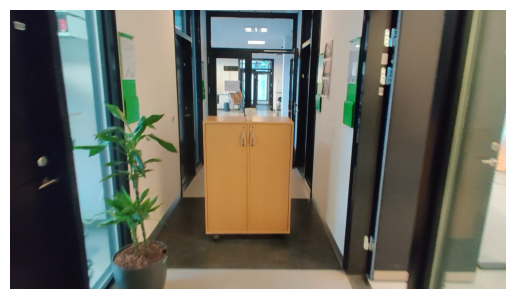

In [39]:
input_frame = read_video_frames(video_path)[frame_index]

display_image(input_frame)

Get 2d bounding boxes

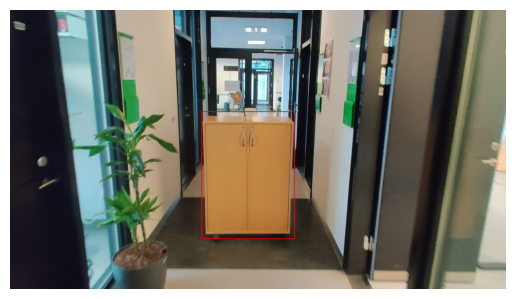

In [40]:
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

display_image(frame_with_boxes)

Directly convert image to ImageChunk and detect 3d bounding boxes

In [45]:
chunk = image_chunk_from_undistorted(input_frame)
bb_centers, bb_dimensions, bb_poses = get_3d_bounding_boxes(chunk, object_class, threshold=0.4)

/home/max/miniconda3/envs/instruct360/lib/python3.8/site-packages/transformers/modeling_utils.py:1161: FutureWarning:

The `device` argument is deprecated and will be removed in v5 of Transformers.

/home/max/miniconda3/envs/instruct360/lib/python3.8/site-packages/torch/_dynamo/eval_frame.py:600: UserWarning:

torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.

/home/max/miniconda3/envs/instruct360/lib/python3.8/site-packages/torch/utils/checkpoint.py:92: UserWarning:

None of the inputs have requires_grad=True. Gradients will be None

/home/max/Documents/RA/instruct360/GroundingDINO/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning:

`torch.cuda.amp.autocast(args..

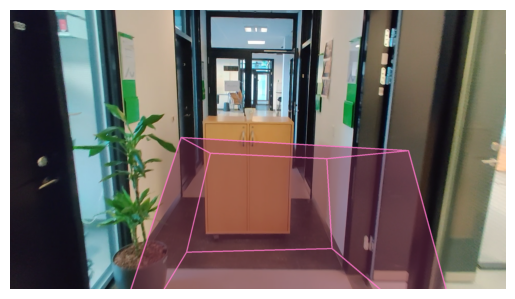

In [46]:
image_with_3d_boxes = draw_3d_bounding_boxes(chunk, bb_centers, bb_dimensions, bb_poses)
display_image(image_with_3d_boxes)

In [44]:
import open3d as o3d
bb_meshes = get_box_meshes((bb_centers, bb_dimensions, bb_poses))
character_placeholder = get_character_placeholder()

coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])

render_scene(bb_meshes + [character_placeholder, coordinate_frame])